In [89]:
# ── Dependency Guard ───────────────────────────────────────────────
import importlib, subprocess, sys

_REQUIRED = {
    'numpy': 'numpy',
    'pandas': 'pandas',
    'sklearn': 'scikit-learn',
    'matplotlib': 'matplotlib',
    'seaborn': 'seaborn',
    'scipy': 'scipy',
    
}

_missing = []
for _mod, _pip in _REQUIRED.items():
    try:
        importlib.import_module(_mod)
    except ModuleNotFoundError:
        _missing.append(_pip)

if _missing:
    print(f'Installing missing packages: {_missing}')
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '--quiet'] + _missing)
    print('Done. Packages installed successfully.')
else:
    print('All required packages already installed ✓')

# ── Library Imports ───────────────────────────────────────────────
import os                        # Working directory checks
import subprocess                # Git command checks
import importlib                 # Runtime dependency checks
import numpy as np               # Numeric support
import pandas as pd              # Tables and diagnostics
import matplotlib.pyplot as plt  # Plotting
import seaborn as sns            # Statistical plotting
from scipy.stats import pearsonr, spearmanr, contingency

All required packages already installed ✓


In [90]:
# ── Reproducibility Header ────────────────────────────────────────────

import sys, random
import numpy as np
import warnings
import requests

RANDOM_SEED = 414  # Course constant. Do not change.
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
warnings.filterwarnings('ignore', category=FutureWarning)

# Environment check
print(f'Python  : {sys.version.split()[0]}')
print(f'NumPy   : {np.__version__}')
print(f'Seed    : {RANDOM_SEED}')

Python  : 3.12.3
NumPy   : 2.4.3
Seed    : 414


In [121]:
def get_season_results(year: int) -> pd.DataFrame:
    
    offset = 0
    limit = 100
    rows = []

    while True:
        url = f"https://api.jolpi.ca/ergast/f1/{year}/results.json?limit={limit}&offset={offset}"
        response = requests.get(url, timeout=30)
        response.raise_for_status()

        data = response.json()['MRData']
        total = int(data['total'])
        races = data['RaceTable']['Races']

        for race in races:
            for result in race['Results']:
                rows.append({
                    'season': int(race['season']),
                    'round': int(race['round']),
                    'race_name': race['raceName'],
                    'circuit': race['Circuit']['circuitId'],
                    'date': race['date'],
                    'driver': result['Driver']['driverId'],
                    'driver_name': f"{result['Driver']['givenName']} {result['Driver']['familyName']}",
                    'constructor': result['Constructor']['constructorId'],
                    'grid': int(result['grid']),
                    'position': int(result['position']) if result['position'].isdigit() else None,
                    'points': float(result['points']),
                    'status': result['status'],
                    'laps': int(result['laps']),
                })

        offset += limit

        if offset >= total:
            break

    return pd.DataFrame(rows)

seasons = [2023, 2024]
dfs = []

for year in seasons:
    df_year = get_season_results(year)
    print(f"{year}: {len(df_year)} rows, {df_year['round'].nunique()} races")
    dfs.append(df_year)

df = pd.concat(dfs, ignore_index=True)
df['date'] = pd.to_datetime(df['date'])
df['top10'] = (df['position'] <= 10)
df['position_change'] = df['grid'] - df['position']

2023: 440 rows, 22 races
2024: 479 rows, 24 races


In [119]:
df

,season,round,race_name,circuit,date,driver,driver_name,constructor,grid,position,points,status,laps,top10,position_change
0,2023,1,Bahrain Grand Prix,bahrain,2023-03-05,max_verstappen,Max Verstappen,red_bull,1,1,25.0,Finished,57,True,0
1,2023,1,Bahrain Grand Prix,bahrain,2023-03-05,perez,Sergio Pérez,red_bull,2,2,18.0,Finished,57,True,0
2,2023,1,Bahrain Grand Prix,bahrain,2023-03-05,alonso,Fernando Alonso,aston_martin,5,3,15.0,Finished,57,True,-2
3,2023,1,Bahrain Grand Prix,bahrain,2023-03-05,sainz,Carlos Sainz,ferrari,4,4,12.0,Finished,57,True,0
4,2023,1,Bahrain Grand Prix,bahrain,2023-03-05,hamilton,Lewis Hamilton,mercedes,7,5,10.0,Finished,57,True,-2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
914,2024,24,Abu Dhabi Grand Prix,yas_marina,2024-12-08,kevin_magnussen,Kevin Magnussen,haas,14,16,0.0,Lapped,57,False,2
915,2024,24,Abu Dhabi Grand Prix,yas_marina,2024-12-08,lawson,Liam Lawson,rb,12,17,0.0,Retired,55,False,5
916,2024,24,Abu Dhabi Grand Prix,yas_marina,2024-12-08,bottas,Valtteri Bottas,sauber,9,18,0.0,Retired,30,False,9
917,2024,24,Abu Dhabi Grand Prix,yas_marina,2024-12-08,colapinto,Franco Colapinto,williams,20,19,0.0,Retired,26,False,-1


## Question 1
Does starting position influence finishing within the Top-10?

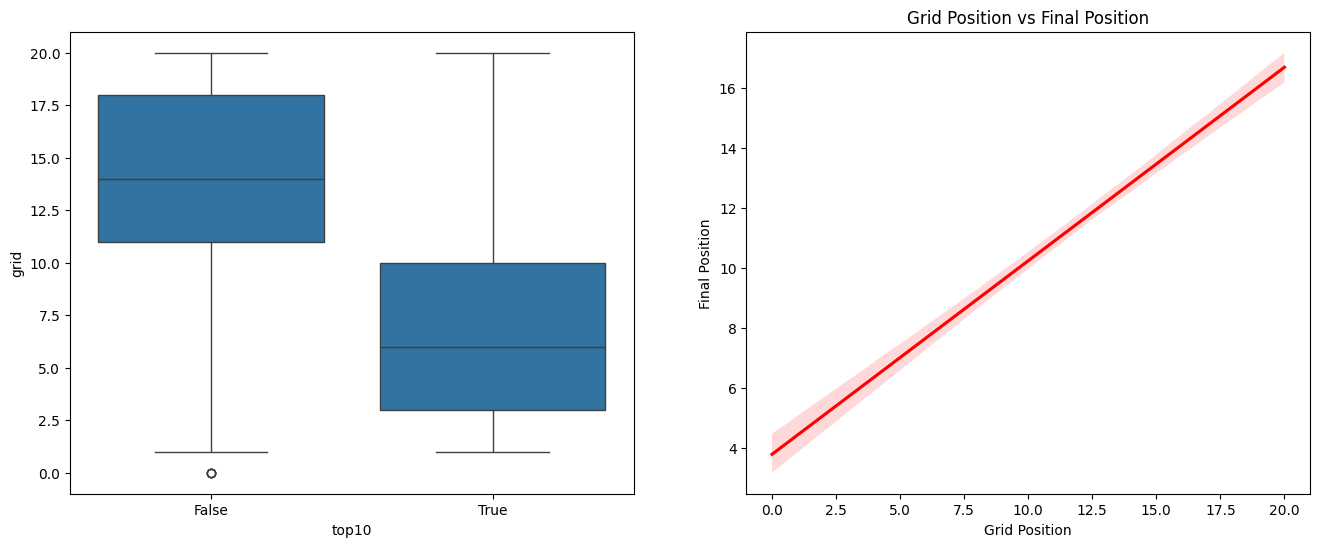

,season,round,race_name,circuit,date,driver,driver_name,constructor,grid,position,points,status,laps,top10
255,2023,13,Dutch Grand Prix,zandvoort,2023-08-27,kevin_magnussen,Kevin Magnussen,haas,0,16,0.0,Finished,72,False
299,2023,15,Singapore Grand Prix,marina_bay,2023-09-17,stroll,Lance Stroll,aston_martin,0,20,0.0,Withdrew,0,False
376,2023,19,Mexico City Grand Prix,rodriguez,2023-10-29,stroll,Lance Stroll,aston_martin,0,17,0.0,Collision damage,66,False
831,2024,20,Mexico City Grand Prix,rodriguez,2024-10-27,ocon,Esteban Ocon,alpine,0,13,0.0,Lapped,70,False


In [93]:
fig, ax = plt.subplots(1, 2, figsize=(16,6))

sns.boxplot(data=df, x="top10", y="grid", ax=ax[0])
plt.title("Grid Position vs Top-10 Finish")
plt.xlabel("Top-10 Finish")
plt.ylabel("Grid Position")

sns.regplot(data=df, x="grid", y="position", scatter=False, color="red", ax=ax[1])
plt.title("Grid Position vs Final Position")
plt.xlabel("Grid Position")
plt.ylabel("Final Position")

plt.show()

df[df["grid"] == 0]

### Interpretation

As we can see from the box plot, the drivers who finish in the top 10 are usually those who start from a high position on the grid. There is some outlieres who started in position 0, which is odd since the grid starts at 1. What may have happened is that these drivers entered the race from the pit lane.

In the line graph, we can see that there is a linear relationship between grid position and final position; that is, those who start in the front of the grid tend to finish in higher positions.

It should be noted that in this case, the runners marked with grid 0 break the scale, since 0 does not mean further ahead than 1; on the contrary, it indicates that they started the race much later than most, and therefore they would be considered outliers in this case.

### Decision

The **grid** variable is an important predictor for models that try to anticipate race results, also is a pre-race variable, so we can use it to predict without data leakage.

## Question 2
Which builders have the best average results?

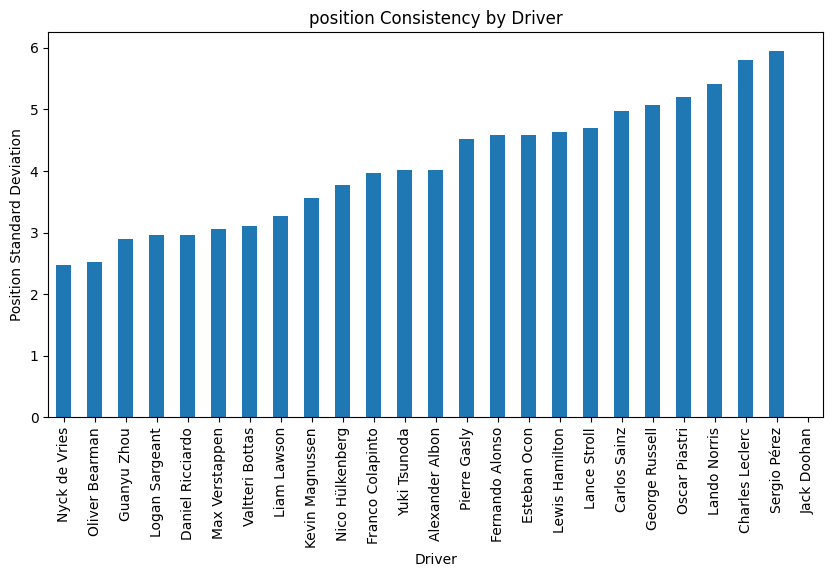

,season,round,race_name,circuit,date,driver,driver_name,constructor,grid,position,points,status,laps,top10,finished
913,2024,24,Abu Dhabi Grand Prix,yas_marina,2024-12-08,doohan,Jack Doohan,alpine,17,15,0.0,Lapped,57,False,False


In [104]:
pilot_variability = (df.groupby("driver_name")["position"].std().sort_values())

plt.figure(figsize=(10,5))

pilot_variability.plot(kind="bar")

plt.title("position Consistency by Driver")
plt.xlabel("Driver")
plt.ylabel("Position Standard Deviation")
plt.show()

df[df["driver_name"] == "Jack Doohan"]

### Interpretation
Although we can draw certain conclusions from this data, there are many factors to consider regarding this metric, such as the amount of data, since not all runners have the same number of races. (In fact, Jack Doohan has a deviation of 0 because he has only run one race.) We cannot evaluate all metrics as if they were equivalent.


### Decision

Additional metrics, such as the coefficient of variation, should be evaluated, and factors such as accidents should be taken into account 

## Question 3
which constructors have the best results?

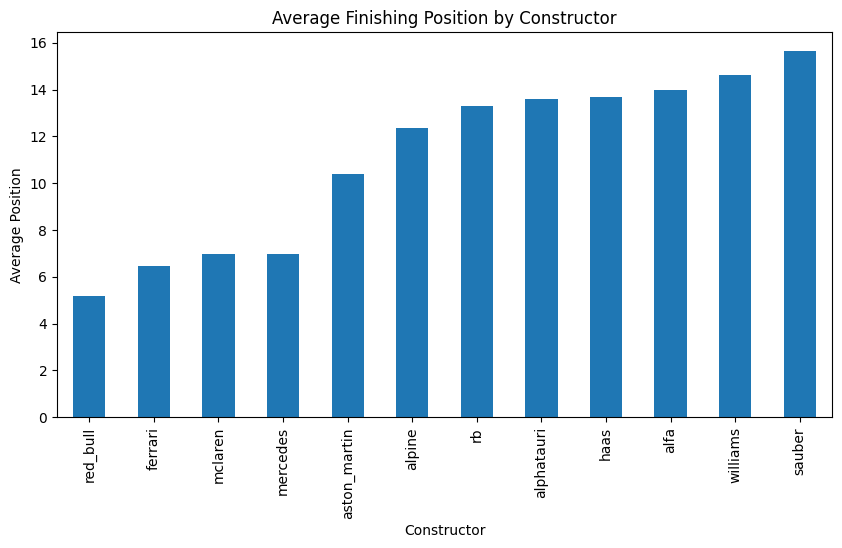

In [110]:
team_performance = (
    df.groupby("constructor")["position"]
    .mean()
    .sort_values()
)

plt.figure(figsize=(10,5))

team_performance.plot(kind="bar")

plt.title("Average Finishing Position by Constructor")
plt.xlabel("Constructor")
plt.ylabel("Average Position")
plt.show()

### Interpretation

Of course, the teams with the best rankings are the best-known ones, led by Red Bull, closely followed by Ferrari, McLaren, and Mercedes. It’s interesting that the latter two have the same average score.

### Decision
It would be interesting to investigate what makes them perform better and why McLaren and Mercedes have the same score.



## Question 4
Which drivers tend to make up the most positions during the race?

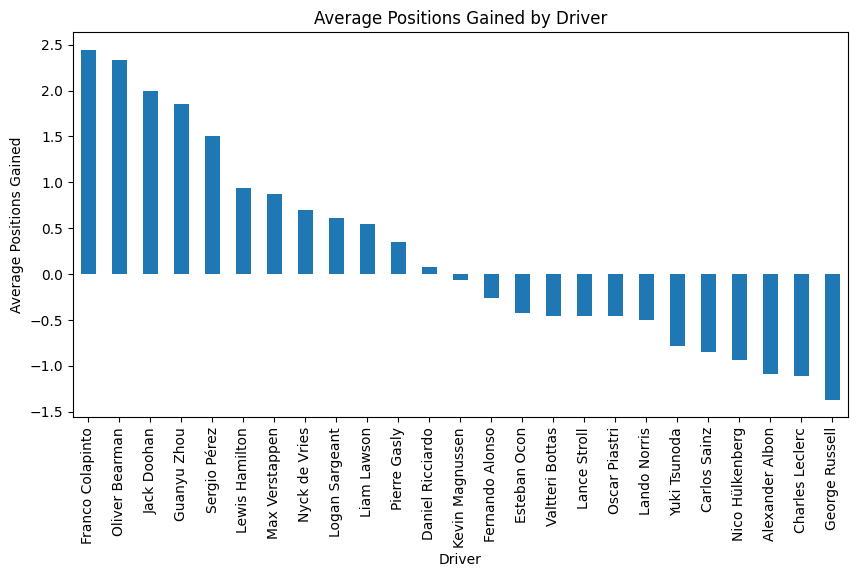

In [122]:
position_gain = (df.groupby("driver_name")["position_change"].mean().sort_values(ascending=False))

plt.figure(figsize=(10,5))
position_gain.plot(kind="bar")

plt.title("Average Positions Gained by Driver")
plt.xlabel("Driver")
plt.ylabel("Average Positions Gained")
plt.show()

### Interpretation

First of all, it’s important to note that the difference in position is calculated as grid position minus final position; therefore, if the result is positive, it means the driver finished ahead of their starting position, while a negative result means they finished behind their starting position.

The graph shows that the change in rankings is not significant in either case, as the variation between rankings is only about two places, whether positive or negative.

### Decision

Given that the race has a total of 20 finishers, a variation of 2 isn’t that significant; nevertheless, this data helps us see whether a runner tends to improve or worsen their position, which can be very useful for measuring runners’ performance

## Question 5
¿Qué variables numéricas se correlacionan con terminar en Top-10?

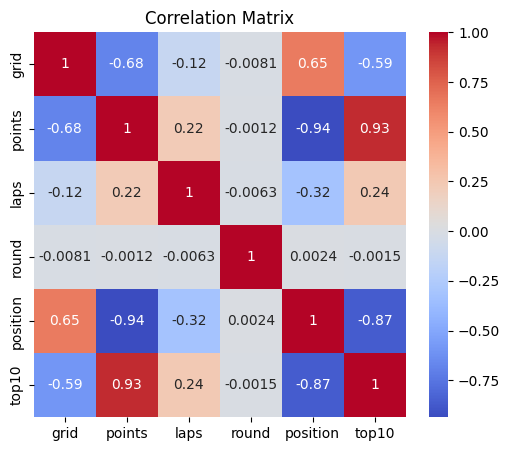

In [123]:
features = ["grid", "points", "laps", "round", "position"]

corr = df[features + ["top10"]].corr(method="spearman")

plt.figure(figsize=(6,5))
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()

### Interpretation

We can see that there are several variables that are highly correlated with one another, such as points and top 10. The problem is that they are correlated because they are interdependent variables; that is, the more points you have, the higher you will naturally rank. Furthermore, most of these variables are post-season, so they are not very useful in a predictive model. 
On the other hand, the relationship between grid and position is confirmed once again, given that they have a correlation of 0.65, which is quite high.

### Decision

It won't be very useful to rely on the correlation between these variables to justify decisions; we need to look for other data that fits this pattern.

# Class Balance analysis
**Top-10 vs non-Top-10** 

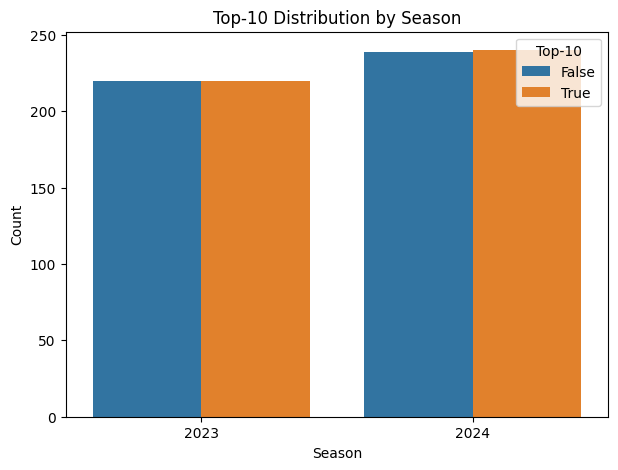

In [98]:
plt.figure(figsize=(7,5))
sns.countplot(data=df, x="season", hue='top10')
plt.title("Top-10 Distribution by Season")
plt.xlabel("Season")
plt.ylabel("Count")
plt.legend(title="Top-10")
plt.show()

As we can see, the classes are well balanced in both seasons. In 2024 there is a minimal difference, But it's so minimal it won't have an impact on the model.

If there had been a much greater imbalance between the classes, it would have been a problem for the model, since it would tend to predict the majority class simply because it has more data, which does not demonstrate accuracy. In fact, if we were to calculate the model’s "accuracy" value, it would give us an extremely high value, but this would only mean that the model is taking advantage of the imbalance, not making accurate predictions.

## Trap Check:

In [124]:
# Trap checks for common analytical biases
trap = {}

# 1) Spurious correlation / leakage-like relationship
trap['corr_points_top10'] = df['points'].corr(df['top10'].astype(int), method='spearman')
trap['corr_position_top10'] = df['position'].corr(df['top10'].astype(int), method='spearman')

# 2) Survivorship bias: DNFs/DSQs (non-numeric position)
total_rows = len(df)
non_finishers = df['position'].isna().sum()
trap['non_finisher_rate'] = non_finishers / total_rows

# What happens if we drop non-finishers?
top10_full = df['top10'].mean()
top10_only_finishers = df[df['position'].notna()]['top10'].mean()
trap['top10_rate_full'] = top10_full
trap['top10_rate_finishers_only'] = top10_only_finishers

# 3) Anchoring bias: over-trusting starting grid
trap['top10_given_grid_le_10'] = df[df['grid'] <= 10]['top10'].mean()
trap['top10_given_grid_gt_10'] = df[df['grid'] > 10]['top10'].mean()
trap['upset_rate_grid_gt_10_to_top10'] = trap['top10_given_grid_gt_10']
trap['miss_rate_grid_le_10_not_top10'] = 1 - trap['top10_given_grid_le_10']

trap_df = pd.DataFrame([trap]).T
trap_df.columns = ['value']
trap_df

,value
corr_points_top10,0.926131
corr_position_top10,-0.867110
non_finisher_rate,0.000000
top10_rate_full,0.500544
top10_rate_finishers_only,0.500544
top10_given_grid_le_10,0.782328
top10_given_grid_gt_10,0.213187
upset_rate_grid_gt_10_to_top10,0.213187
miss_rate_grid_le_10_not_top10,0.217672


### Interpretation

**Spurious correlation**  
Variables such as `points` and `position` show very high association with `top10`, but they are post-race outcomes. Their relationship is not useful for pre-race prediction and can create a false sense of explanatory power (target leakage disguised as strong correlation).

**Survivorship bias**  
If we evaluate only rows with numeric finishing position, we under-represent DNFs/DSQs and overestimate competitive stability. The non-finisher share must remain visible in EDA and model evaluation.

**Anchoring bias**  
`grid` is clearly informative, but relying on it alone is risky. There are still drivers starting outside top-10 who finish in top-10, and drivers starting inside top-10 who fail to finish there. This confirms that grid should be treated as a strong feature, not a deterministic rule.

### Decision

- Exclude post-race variables (`points`, `position`, `laps`, `status`) from pre-race modeling to avoid spurious/leakage effects.
- Keep non-finishers in analysis (or model them explicitly) to prevent survivorship bias.
- Use `grid` with additional pre-race context (constructor, circuit, season effects) to reduce anchoring bias and improve robustness.

# Data Quality Audit

In [125]:
df.info()
df.isna().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 919 entries, 0 to 918
Data columns (total 15 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   season           919 non-null    int64         
 1   round            919 non-null    int64         
 2   race_name        919 non-null    object        
 3   circuit          919 non-null    object        
 4   date             919 non-null    datetime64[ns]
 5   driver           919 non-null    object        
 6   driver_name      919 non-null    object        
 7   constructor      919 non-null    object        
 8   grid             919 non-null    int64         
 9   position         919 non-null    int64         
 10  points           919 non-null    float64       
 11  status           919 non-null    object        
 12  laps             919 non-null    int64         
 13  top10            919 non-null    bool          
 14  position_change  919 non-null    int64    

season             0
round              0
race_name          0
circuit            0
date               0
driver             0
driver_name        0
constructor        0
grid               0
position           0
points             0
status             0
laps               0
top10              0
position_change    0
dtype: int64

## Data Types

Numéricas:
- grid
- position
- points
- laps
- round

Categóricas:
- driver
- constructor
- circuit
- status

Temporales:
- date

## Outliers

Valores bajos de laps pueden indicar abandono temprano.

## Temporal Availability

Pre-race:
- season 
- race_name
- circuit
- date
- driver
- driver_name
- constructor
- grid

Post-race:
- position
- points
- status
- laps

Created for this analisis:

- top10
- position_change

### Outlier check with IQR for grid and position

,column,q1,q3,iqr,lower_bound,upper_bound,outliers_count,outliers_pct
0,grid,5.0,15.0,10.0,-10.00,30.00,0,0.0
1,position,5.5,15.0,9.5,-8.75,29.25,0,0.0


Sample outliers for grid:


,season,round,race_name,driver_name,constructor,grid,position


Sample outliers for position:


,season,round,race_name,driver_name,constructor,grid,position


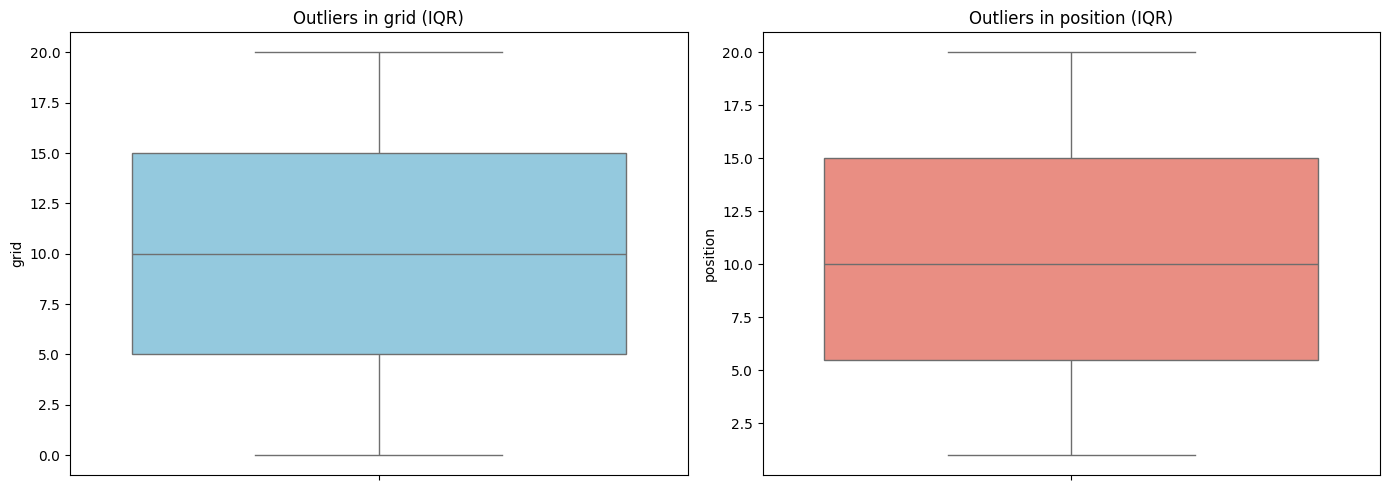

In [ ]:
cols = ['grid', 'position']
outlier_rows = {}
summary = []

for col in cols:
    series = df[col].dropna()
    q1 = series.quantile(0.25)
    q3 = series.quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr

    mask = df[col].notna() & ((df[col] < lower) | (df[col] > upper))
    outlier_rows[col] = df.loc[mask, ['season', 'round', 'race_name', 'driver_name', 'constructor', 'grid', 'position']]
    
    summary.append({
        'column': col,
        'q1': q1,
        'q3': q3,
        'iqr': iqr,
        'lower_bound': lower,
        'upper_bound': upper,
        'outliers_count': int(mask.sum()),
        'outliers_pct': round(mask.mean() * 100, 2)
    })

outlier_summary = pd.DataFrame(summary)
display(outlier_summary)

print('Sample outliers for grid:')
display(outlier_rows['grid'].head(10))

print('Sample outliers for position:')
display(outlier_rows['position'].head(10))

fig, ax = plt.subplots(1, 2, figsize=(14, 5))
sns.boxplot(data=df, y='grid', ax=ax[0], color='skyblue')
ax[0].set_title('Outliers in grid (IQR)')
ax[0].set_ylabel('grid')

sns.boxplot(data=df, y='position', ax=ax[1], color='salmon')
ax[1].set_title('Outliers in position (IQR)')
ax[1].set_ylabel('position')

plt.tight_layout()
plt.show()

## Temporal Train / Validation / Test Split

In [126]:
train = df[df["season"] == 2023]

val = df[(df["season"] == 2024) & (df["round"] <= 10)]

test = df[(df["season"] == 2024) & (df["round"] > 10)]

len(train), len(val), len(test)

(440, 199, 280)

### Why?

Train: 2023 season  
Validation: First races of 2024 season  
Test: Final races of 2024 season de 2024

This preserves the chronological order and prevents data leakage.

# 1-3-1 Summary

**1 Insight**

La posición de salida es el predictor pre-carrera más fuerte para terminar en el Top-10.

**3 Supporting Points**

- Existe correlación negativa clara entre grid y Top-10.
- La distribución del target es consistente entre temporadas.
- Algunos constructores tienen probabilidades significativamente mayores de terminar en Top-10.

**1 Decision**

Los modelos predictivos deben centrarse en variables disponibles antes de la carrera, especialmente grid position y constructor.